In [1]:
#import Libraries

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
fgi = pd.read_csv('fear_greed_index.csv')
hd  = pd.read_csv('historical_data.csv')

In [4]:
fgi.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [5]:
fgi.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [6]:
fgi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [7]:
fgi.shape

(2644, 4)

In [8]:
fgi.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

In [9]:
fgi.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [10]:
# we can see that date column data type is in object we will chn=ang it to date
fgi['date'] = pd.to_datetime(fgi['date'])

In [11]:
# also there is a timestamp column is in int we need itss data type to timestamp
fgi['timestamp'] = pd.to_datetime(fgi['timestamp'], unit='s')

In [12]:
fgi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   timestamp       2644 non-null   datetime64[ns]
 1   value           2644 non-null   int64         
 2   classification  2644 non-null   object        
 3   date            2644 non-null   datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(1)
memory usage: 82.8+ KB


In [13]:
fgi['classification'].unique()

array(['Fear', 'Extreme Fear', 'Neutral', 'Greed', 'Extreme Greed'],
      dtype=object)

In [14]:
fgi['classification'].value_counts()

classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64

In [15]:
hd.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [16]:
hd.tail()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,382.2,420.80,SELL,25-04-2025 15:35,7546.6,Close Long,-20.2566,0xcd339c08dc7b615a993c0422374d8e02027400092bc2...,88803313862,False,0.042080,1.990000e+14,1.750000e+12
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,2124.1,2338.63,SELL,25-04-2025 15:35,7164.4,Close Long,-112.5773,0x29e8ede2a3a37aa0eac00422374d8e02029b00ac9f3c...,88803313862,False,0.233863,9.260000e+14,1.750000e+12
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,423.4,466.16,SELL,25-04-2025 15:35,5040.3,Close Long,-22.4402,0x0780085b0c0a943eea800422374d920204c100edf579...,88803313862,False,0.046616,6.930000e+14,1.750000e+12
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,3599.8,3963.38,SELL,25-04-2025 15:35,4616.9,Close Long,-190.7894,0x349c29934913b25c89e20422374d920204cd008b8a0e...,88803313862,False,0.396337,4.180000e+14,1.750000e+12
211223,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,1017.1,1119.83,SELL,25-04-2025 15:35,1017.1,Close Long,-53.9063,0xac77fab973c455d77a670422374d9602039800f1f78c...,88803313862,False,0.111982,3.270000e+14,1.750000e+12


In [17]:
hd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [18]:
hd.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

In [19]:
hd.shape

(211224, 16)

In [20]:
hd['Timestamp IST'].head()

0    02-12-2024 22:50
1    02-12-2024 22:50
2    02-12-2024 22:50
3    02-12-2024 22:50
4    02-12-2024 22:50
Name: Timestamp IST, dtype: object

In [21]:
hd['Timestamp IST'] = pd.to_datetime(hd['Timestamp IST'], format='%d-%m-%Y %H:%M')
hd['date'] = hd['Timestamp IST'].dt.date

In [22]:
hd['date'] = pd.to_datetime(hd['date']) 

In [23]:
hd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  object        
 1   Coin              211224 non-null  object        
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side              211224 non-null  object        
 6   Timestamp IST     211224 non-null  datetime64[ns]
 7   Start Position    211224 non-null  float64       
 8   Direction         211224 non-null  object        
 9   Closed PnL        211224 non-null  float64       
 10  Transaction Hash  211224 non-null  object        
 11  Order ID          211224 non-null  int64         
 12  Crossed           211224 non-null  bool          
 13  Fee               211224 non-null  float64       
 14  Trad

In [24]:
hd.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
date                0
dtype: int64

In [25]:
hd.duplicated().sum()

0

In [26]:
merged = hd.merge(fgi[['date','classification','value']], on='date', how='left')

# Quick check
print(merged[['date','classification']].head())

        date classification
0 2024-12-02  Extreme Greed
1 2024-12-02  Extreme Greed
2 2024-12-02  Extreme Greed
3 2024-12-02  Extreme Greed
4 2024-12-02  Extreme Greed


In [27]:
print("Unmatched sentiment rows:", merged['classification'].isna().sum())

Unmatched sentiment rows: 6


In [28]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  object        
 1   Coin              211224 non-null  object        
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side              211224 non-null  object        
 6   Timestamp IST     211224 non-null  datetime64[ns]
 7   Start Position    211224 non-null  float64       
 8   Direction         211224 non-null  object        
 9   Closed PnL        211224 non-null  float64       
 10  Transaction Hash  211224 non-null  object        
 11  Order ID          211224 non-null  int64         
 12  Crossed           211224 non-null  bool          
 13  Fee               211224 non-null  float64       
 14  Trad

In [29]:
merged.shape

(211224, 19)

In [30]:
merged.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'date', 'classification', 'value'],
      dtype='object')

In [31]:
merged.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
date                0
classification      6
value               6
dtype: int64

In [32]:
merged['classification'].value_counts()

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

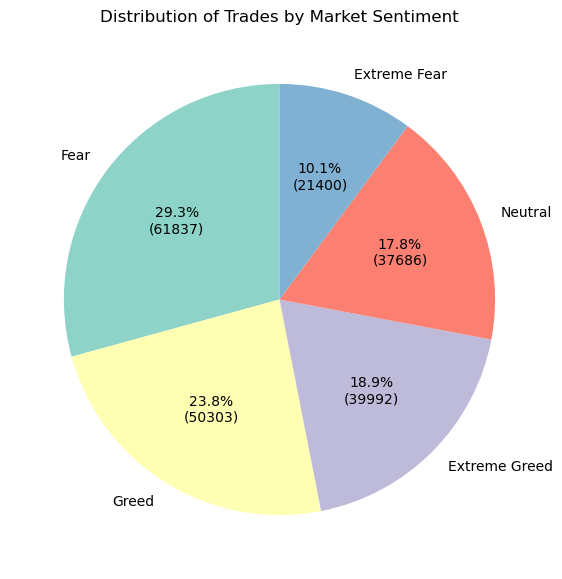

In [33]:
# Count the occurrences of each classification
counts = merged['classification'].value_counts()

# Function to display both percentage and value
def autopct_format(pct, allvals):
    absolute = int(round(pct/100.*sum(allvals)))
    return f"{pct:.1f}%\n({absolute})"

# Plot pie chart
plt.figure(figsize=(7,7))
plt.pie(
    counts,
    labels=counts.index,
    autopct=lambda pct: autopct_format(pct, counts),
    startangle=90,
    colors=plt.cm.Set3.colors
)

plt.title("Distribution of Trades by Market Sentiment")
plt.show()

### Key Insights

- **Fear dominates** with nearly one-third of trades (**29.3%**), showing cautious investor behavior.  
- **Greed + Extreme Greed together** account for **42.7%**, suggesting a strong bullish sentiment overall.  
- **Neutral trades** are relatively low (**17.8%**), meaning most traders lean toward emotional extremes rather than balance.  
- The split between **fear (39.4%)** and **greed (42.7%)** is fairly even, highlighting a tug-of-war in market psychology.  


In [34]:
merged = merged.dropna(subset=['classification'])

In [35]:
merged.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
date                0
classification      0
value               0
dtype: int64

In [36]:
merged['classification'].value_counts()

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

In [37]:
merged['Account'].value_counts()

Account
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    40184
0xbaaaf6571ab7d571043ff1e313a9609a10637864    21192
0xa0feb3725a9335f49874d7cd8eaad6be45b27416    15605
0x8477e447846c758f5a675856001ea72298fd9cb5    14998
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    14733
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    13311
0x513b8629fe877bb581bf244e326a047b249c4ff1    12236
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4     9893
0x47add9a56df66b524d5e2c1993a43cde53b6ed85     8519
0x4f93fead39b70a1824f981a54d4e55b278e9f760     7584
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd     7280
0xb899e522b5715391ae1d4f137653e7906c5e2115     4838
0x8170715b3b381dffb7062c0298972d4727a0a63b     4601
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4     4356
0x083384f897ee0f19899168e3b1bec365f52a9012     3818
0x271b280974205ca63b716753467d5a371de622ab     3809
0x39cef799f8b69da1995852eea189df24eb5cae3c     3589
0x2c229d22b100a7beb69122eed721cee9b24011dd     3239
0x92f17e8d81a944691c10e753af1b1baae1a2cd0d     3052
0xbd

In [38]:
merged.head(3)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0


In [39]:
summary = merged.groupby('classification').agg(
    avg_pnl = ('Closed PnL','mean'),
    total_pnl = ('Closed PnL','sum'),
    avg_trade_size = ('Size USD','mean'),
    num_trades = ('Account','count'),
    win_rate = ('Closed PnL', lambda x: (x>0).mean())
).reset_index()


In [40]:
summary

,classification,avg_pnl,total_pnl,avg_trade_size,num_trades,win_rate
0,Extreme Fear,34.537862,7.391102e+05,5349.731843,21400,0.370607
1,Extreme Greed,67.892861,2.715171e+06,3112.251565,39992,0.464943
2,Fear,54.290400,3.357155e+06,7816.109931,61837,0.420768
3,Greed,42.743559,2.150129e+06,5736.884375,50303,0.384828
4,Neutral,34.307718,1.292921e+06,4782.732661,37686,0.396991


### Key Insights
- **Extreme Greed** has the **highest average PnL** (≈68) and the **highest win rate** (≈46.5%), suggesting more profitable trades in this sentiment.
- **Fear** shows the **largest total PnL** (≈3.36M) due to a high number of trades, despite a moderate win rate.
- **Extreme Fear** and **Neutral** have lower win rates (≈37–40%), indicating fewer profitable trades.
- **Greed** sentiment yields moderate average PnL but relatively low win rate (≈38.5%).

Overall, **Extreme Greed** stands out as the most favorable sentiment for profitability, while **Extreme Fear** tends to underperform.


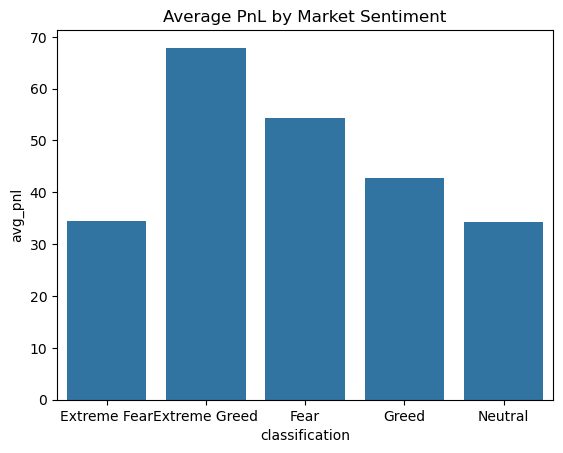

In [41]:
# Bar chart: average PnL by sentiment
sns.barplot(data=summary, x='classification', y='avg_pnl')
plt.title("Average PnL by Market Sentiment")
plt.show()

### Average PnL by Market Sentiment

The bar chart compares **average profit and loss (PnL)** across five market sentiment classifications:

- **Extreme Greed** → Highest average PnL (~68), showing trades are most profitable in this sentiment.
- **Fear** → Second highest (~54), indicating strong profitability despite cautious sentiment.
- **Greed** → Moderate average PnL (~43), less profitable than Fear or Extreme Greed.
- **Extreme Fear** → Lower average PnL (~35), reflecting weaker performance.
- **Neutral** → Similar to Extreme Fear (~34), also among the least profitable.

### Key Takeaway
- Profitability tends to be **highest in Extreme Greed** and **Fear**, while **Neutral** and **Extreme Fear** conditions yield the lowest average returns.
- This suggests that **trading opportunities are more favorable when sentiment is polarized (Extreme Greed or Fear)** compared to balanced or fearful markets.


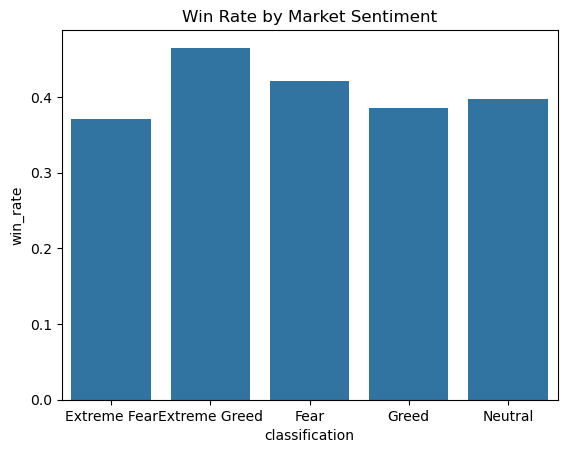

In [42]:
# Bar chart: win rate by sentiment
sns.barplot(data=summary, x='classification', y='win_rate')
plt.title("Win Rate by Market Sentiment")
plt.show()

### Win Rate by Market Sentiment

The bar chart shows how often trades are profitable under different market sentiment conditions:

- **Extreme Greed** → Highest win rate (~46%), meaning trades succeed most often in this sentiment.
- **Fear** → Second highest (~42%), showing relatively strong success.
- **Neutral** → Moderate win rate (~40%), balanced performance.
- **Greed** → Slightly lower (~38%), less consistent than Fear or Neutral.
- **Extreme Fear** → Lowest win rate (~37%), trades are least likely to be profitable.

### Key Takeaway
- **Extreme Greed** offers the best chance of winning trades.
- **Extreme Fear** is the riskiest sentiment, with the lowest success rate.
- Overall, win rates cluster between **37–46%**, suggesting sentiment influences consistency but doesn’t guarantee profitability.

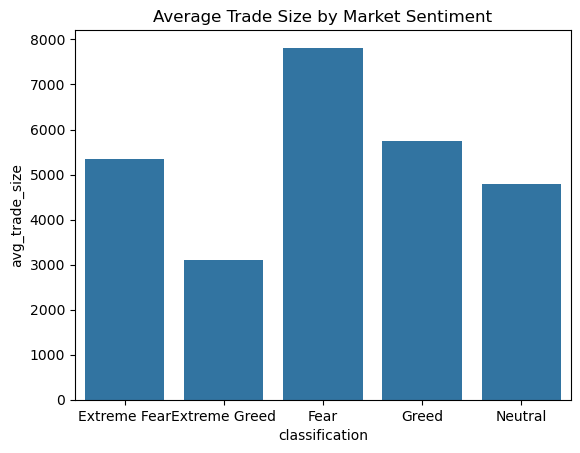

In [43]:
# Bar chart: average trade size by sentiment
sns.barplot(data=summary, x='classification', y='avg_trade_size')
plt.title("Average Trade Size by Market Sentiment")
plt.show()

### Average Trade Size by Market Sentiment

The chart compares how large trades tend to be under different market sentiment conditions:

- **Fear** → Highest average trade size (~7,800), showing traders commit larger positions when sentiment is fearful.
- **Greed** → Second highest (~5,700), indicating strong but smaller commitments compared to Fear.
- **Extreme Fear** → Moderate (~5,300), suggesting cautious but still sizable trades.
- **Neutral** → Lower (~4,800), reflecting balanced, mid-sized trades.
- **Extreme Greed** → Smallest average trade size (~3,100), showing traders prefer smaller positions when sentiment is overly optimistic.

### Key Takeaway
- Traders place **largest bets during Fear**, possibly reflecting conviction or risk-taking in downturns.
- **Extreme Greed** leads to **smaller trades**, suggesting caution or diversification when optimism is very high.
- Overall, trade size varies significantly with sentiment, highlighting how emotions influence position sizing.

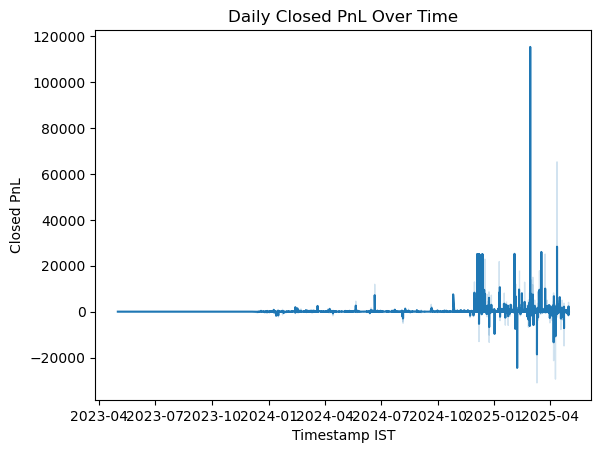

In [44]:
# Line chart of daily Closed PnL
sns.lineplot(data=merged, x='Timestamp IST', y='Closed PnL')
plt.title("Daily Closed PnL Over Time")
plt.show()

In [45]:
# Save mer`ged dataset to CSV
merged.to_csv("merged_trader_sentiment.csv", index=False)